In [1]:
import cvxpy as cp

from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline

import numpy as np

import matplotlib.pyplot as plt

Sets up an optimization-based controller based on the notion of a higher-order control barrier function (HOCBF) using the SymPy derivations in the accompanying notebook. Note that the performance of this function is poor due to the lack of planning on the part of the controller itself.

In [50]:
def create_opt_cntrl(
    u: cp.Variable,
    u_min,  # elementwise constraints
    u_max,  # elementwise constraints
    delta: cp.Variable,
    u_cost,  # cost matrix for the controls
    p,
    k1,  # hoclf constant
    k2,  # hoclf constant
    alpha,  # cost due to position error
    beta,  # cost due to angular error
    x,  # current x
    y,  # current y
    theta,  # current theta
    v,  # current v
    omega,  # current omega
    x_traj,  # current x_traj
    y_traj,  # current y_traj
    theta_traj,  # current theta_traj
    dot_x_traj,  # current dot_x_traj
    dot_y_traj,  # current dot_y_traj
    dot_theta_traj,  # current dot_theta_traj
    ddot_x_traj,
    ddot_y_traj,
    ddot_theta_traj,
):
    cost = 0.5 * cp.quad_form(u, u_cost) + p * cp.square(delta)

    # builds the Lyapunov trajectory following constraint
    Lf_Lf_v = (
        alpha * v**2
        + (
            alpha * (x_traj - x) * np.sin(theta) * v
            - alpha * (y_traj - y) * np.cos(theta) * v
            + beta * omega
        )
        * omega
    )
    Lf1_Lf_v = alpha * ((x - x_traj) * np.cos(theta) + (y - y_traj) * np.sin(theta))
    Lf2_Lf_v = beta * (theta - theta_traj)

    d2v_dt2 = (
        alpha
        * (
            (x_traj - x) * ddot_x_traj
            + (y_traj - y) * ddot_y_traj
            + ddot_x_traj**2
            + ddot_y_traj**2
        )
        + beta * (theta_traj - theta) * ddot_theta_traj
        + beta * (ddot_theta_traj) ** 2
    )

    o_v_fn = k1 * (
        alpha * ((x_traj - x) * dot_x_traj + (y_traj - y) * dot_y_traj)
        - alpha * (x_traj - x) * np.cos(theta) * v
        - alpha * (y_traj - y) * np.sin(theta) * v
        - beta * (theta_traj - theta) * omega
        + beta * (theta_traj - theta) * dot_theta_traj
    )
    final_term = k2 * (
        2 * alpha * ((x_traj - x) * dot_x_traj + (y_traj - y) * dot_y_traj)
        + 2 * beta * (theta_traj - theta) * dot_theta_traj
        + k1
        * (
            alpha * ((x_traj - x) ** 2 + (y_traj - y) ** 2)
            + beta * (theta_traj - theta) ** 2
        )
    )

    lpv_constraint = (
        Lf_Lf_v + np.array([[Lf1_Lf_v, Lf2_Lf_v]]) @ u + d2v_dt2 + o_v_fn + final_term
        <= delta
    )

    problem = cp.Problem(
        cp.Minimize(cost),
        [
            lpv_constraint,
            # need to enforce these constraints by element
            u[0] <= u_max[0],
            u[1] <= u_max[1],
            u[0] >= u_min[0],
            u[1] >= u_min[1],
        ],
    )
    return problem

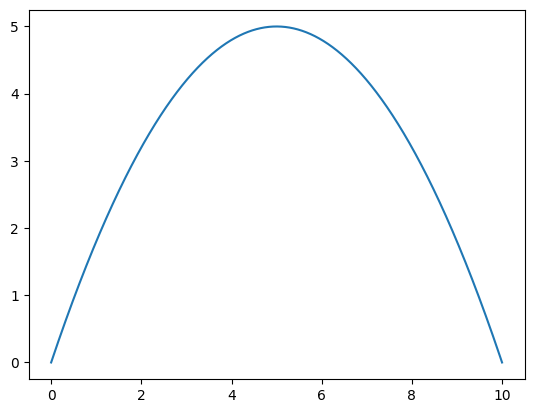

In [51]:
t_f = 60.0
dt = 0.01

n_samples = int(t_f / dt)

spline_method = CubicSpline

t = np.linspace(0, t_f, n_samples)
path_points = np.array([(0.0, 0.0, 0.0), (5.0, 5.0, t_f / 2), (10.0, 0.0, t_f)])

x_spline, y_spline = (
    spline_method(path_points[:, 2], path_points[:, 0]),
    spline_method(path_points[:, 2], path_points[:, 1]),
)
x_traj, y_traj, dot_x_traj, dot_y_traj, ddot_x_traj, ddot_y_traj = (
    x_spline(t),
    y_spline(t),
    x_spline.derivative()(t),
    y_spline.derivative()(t),
    x_spline.derivative().derivative()(t),
    y_spline.derivative().derivative()(t),
)

theta_traj, dot_theta_traj, ddot_theta_traj = (
    np.atan2(y_traj, x_traj),
    np.atan2(dot_y_traj, dot_x_traj),
    np.atan2(ddot_y_traj, ddot_x_traj),
)

fig, ax = plt.subplots()
ax.plot(x_traj, y_traj)
plt.show()

In [56]:
def dyn_unicycle_f(t, p, u):
    x, y, theta, v, omega = p
    u_f, u_t = u

    dot_p = np.array([v * np.cos(theta), v * np.sin(theta), omega, u_f, u_t])
    return dot_p


U_COST = np.array([[1.0, 0.0], [0.0, 1.5]])

ALPHA = 2.0
BETA = 3.0
P = 1e5

K1 = 1.0
K2 = 1.0

U_MIN = np.vstack((-1.0, -0.5))
U_MAX = np.vstack((1.0, 0.5))

u = cp.Variable((2,))
delta = cp.Variable()

p0 = np.array([0.0, 0.0, np.pi / 2, 0.0, 0.0])
u0 = np.array([0.0, 0.0])

p_hist = []
u_hist = []

p_curr = p0
u_curr = u0
for i in range(len(t)):
    p_hist.append(p_curr)
    u_hist.append(u_curr)

    # gets the current state and trajectory
    x_curr, y_curr, theta_curr, v_curr, omega_curr = p_curr
    x_traj_curr, y_traj_curr, theta_traj_curr = (x_traj[i], y_traj[i], theta_traj[i])
    dot_x_traj_curr, dot_y_traj_curr, dot_theta_traj_curr = (
        dot_x_traj[i],
        dot_y_traj[i],
        dot_theta_traj[i],
    )
    ddot_x_traj_curr, ddot_y_traj_curr, ddot_theta_traj_curr = (
        ddot_x_traj[i],
        ddot_y_traj[i],
        ddot_theta_traj[i],
    )

    opt_cntrlr = create_opt_cntrl(
        u,
        U_MIN,
        U_MAX,
        delta,
        U_COST,
        P,
        K1,
        K2,
        ALPHA,
        BETA,
        x_curr,
        y_curr,
        theta_curr,
        v_curr,
        omega_curr,
        x_traj_curr,
        y_traj_curr,
        theta_traj_curr,
        dot_x_traj_curr,
        dot_y_traj_curr,
        dot_theta_traj_curr,
        ddot_x_traj_curr,
        ddot_y_traj_curr,
        ddot_theta_traj_curr,
    )

    # generate controls from optimization scheme
    opt_cntrlr_result = opt_cntrlr.solve()

    u_f_optim, u_t_optim = (u.value[0], u.value[1])
    delta_optim = delta.value

    print(f"t: {t[i]:3f}, u_f: {u_f_optim}, u_t: {u_t_optim}, delta: {delta_optim}")

    # run the dynamics assuming the controls remain constant
    ivp_result = solve_ivp(
        lambda t, y: dyn_unicycle_f(t, y, u=np.array([u_f_optim, u_t_optim])),
        [0.0, dt],
        p_curr,
    )
    p_curr = ivp_result.y[:, -1]

    if i > 1000:
        break

# turn into numpy arrays for easy processing later
p_hist = np.asarray(p_hist)
u_hist = np.asarray(u_hist)

t: 0.000000, u_f: 0.0, u_t: -0.5000026847221305, delta: 4.198690801320239
t: 0.010002, u_f: 1.0000001188695076, u_t: -0.500017181649108, delta: 4.911913647722016
t: 0.020003, u_f: 1.0000001552617874, u_t: -0.5000113070954356, delta: 4.907525369354221
t: 0.030005, u_f: 1.0000002315945435, u_t: -0.5000113879991852, delta: 4.903789979316699
t: 0.040007, u_f: 1.0000003069504282, u_t: -0.5000114807775519, delta: 4.900726885632626
t: 0.050008, u_f: 1.000000380750489, u_t: -0.5000115621458526, delta: 4.8983392430651564
t: 0.060010, u_f: 1.0000004527279125, u_t: -0.5000116315559431, delta: 4.896630278651836
t: 0.070012, u_f: 1.0000005226180673, u_t: -0.5000116884885357, delta: 4.895603355194117
t: 0.080013, u_f: 1.0000005901613203, u_t: -0.500011732475186, delta: 4.895261971800855
t: 0.090015, u_f: 1.0000006551042837, u_t: -0.500011763079928, delta: 4.895609764511972
t: 0.100017, u_f: 1.000000717202905, u_t: -0.5000117799240018, delta: 4.8966505067729855
t: 0.110018, u_f: 1.0000007762238097, u

1002

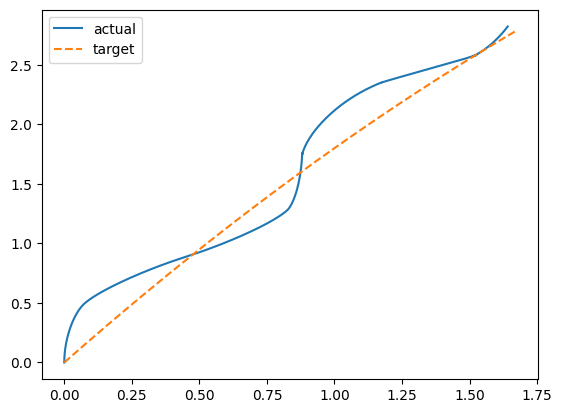

In [57]:
fig, ax = plt.subplots()

num_samples = p_hist.shape[0]

display(num_samples)

ax.plot(p_hist[:, 0], p_hist[:, 1], label="actual")
ax.plot(x_traj[:num_samples], y_traj[:num_samples], "--", label="target")
ax.legend()

In [6]:
x_err = p_hist[:, 0] - x_traj[:num_samples]
y_err = p_hist[:, 1] - y_traj[:num_samples]
theta_err = p_hist[:, 2] - theta_traj[:num_samples]

theta_err

array([ 1.57079633e+00,  4.63654447e-01,  4.63530972e-01,  4.63266619e-01,
        4.62861512e-01,  4.62315751e-01,  4.61629412e-01,  4.60802548e-01,
        4.59835190e-01,  4.58727343e-01,  4.57478991e-01,  4.56090095e-01,
        4.54560591e-01,  4.52890395e-01,  4.51079400e-01,  4.49127477e-01,
        4.47034478e-01,  4.44800233e-01,  4.42424551e-01,  4.39907224e-01,
        4.37248025e-01,  4.34446710e-01,  4.31503018e-01,  4.28416674e-01,
        4.25187388e-01,  4.21814859e-01,  4.18298774e-01,  4.14638809e-01,
        4.10834636e-01,  4.06885920e-01,  4.02792321e-01,  3.98553500e-01,
        3.94169119e-01,  3.89638843e-01,  3.84962347e-01,  3.80139315e-01,
        3.75169443e-01,  3.70052449e-01,  3.64788070e-01,  3.59376071e-01,
        3.53816245e-01,  3.48108427e-01,  3.42252487e-01,  3.36248347e-01,
        3.30095983e-01,  3.23795427e-01,  3.17346784e-01,  3.10750231e-01,
        3.04006028e-01,  2.97114529e-01,  2.90076186e-01,  2.82891563e-01,
        2.75561344e-01,  